/users/course_00239/scratch/gipfelsturm/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


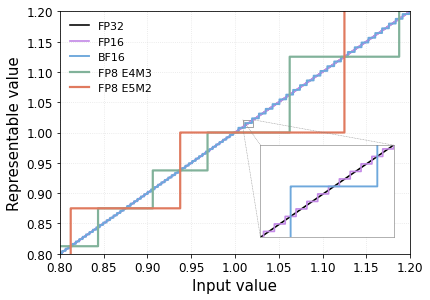

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def float_quantize(x, mant_bits):
    x = np.asarray(x, dtype=float)
    safe_x = np.where(x == 0, 1e-30, x)
    exponent = np.floor(np.log2(np.abs(safe_x)))
    ulp = 2.0 ** (exponent - mant_bits)
    return np.round(x / ulp) * ulp

formats = [
    {
        "name": "FP32",
        "mant": 23,
        "min": 1.2e-38,
        "max": 3.4e38,
        "color": "#000000",   # black
        "lw": 1.6
    },
    {
        "name": "FP16",
        "mant": 10,
        "min": 6.1e-5,
        "max": 6.5e4,
        "color": "#C48AE7",   # light pastel blue
        "lw": 1.7
    },
    {
        "name": "BF16",
        "mant": 7,
        "min": 1.2e-38,
        "max": 3.4e38,
        "color": "#6EA8DC",   # medium muted blue
        "lw": 1.9
    },
    {
        "name": "FP8 E4M3",
        "mant": 3,
        "min": 2**-6,
        "max": 448.0,
        "color": "#81B29A",   # same muted green as ablation
        "lw": 2.2
    },
    {
        "name": "FP8 E5M2",
        "mant": 2,
        "min": 2**-14,
        "max": 57344.0,
        "color": "#E07A5F",   # same muted coral as ablation
        "lw": 2.2
    },
]
smaller = 0.7
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

fig, ax1 = plt.subplots(figsize=(6.2, 4.4))

x_zoom = np.linspace(0.8, 1.2, 5000)

for fmt in formats:
    y_quant = float_quantize(x_zoom, fmt["mant"])
    ax1.step(
        x_zoom,
        y_quant,
        where="post",
        color=fmt["color"],
        lw=fmt["lw"],
        label=fmt["name"],
    )

ax1.set_xlabel("Input value")
ax1.set_ylabel("Representable value")
ax1.set_xlim(0.8, 1.2)
ax1.set_ylim(0.8, 1.2)
ax1.grid(True, linestyle=":", alpha=0.35)

ax1.legend(
    loc="upper left",
    frameon=False,
    ncol=1,
    handlelength=1.8,
    columnspacing=0.9,
)

# Inset magnifier
x1, x2 = 1.009, 1.021
y1, y2 = 1.009, 1.021
x_inset = np.linspace(x1, x2, 15000)

zoom_rect = Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    fill=False,
    edgecolor="0.5",
    linewidth=0.7,
)
ax1.add_patch(zoom_rect)

axins = inset_axes(
    ax1,
    width="38%",
    height="38%",
    loc="lower right",
    borderpad=1.5,
)

for fmt in formats[:3]:
    y_inset = float_quantize(x_inset, fmt["mant"])
    axins.step(
        x_inset,
        y_inset,
        where="post",
        color=fmt["color"],
        lw=fmt["lw"],
    )

axins.plot(x_inset, x_inset, color="black", alpha=0.22, linestyle=":", lw=0.7)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

for spine in axins.spines.values():
    spine.set_linewidth(0.6)
    spine.set_edgecolor("0.5")

connector_style = dict(
    color="0.5",
    linewidth=0.6,
    alpha=0.8,
    linestyle=":",
)

for xy_main, xy_inset in [
    ((x1, y1), (0, 0)),
    ((x1, y2), (0, 1)),
    ((x2, y2), (1, 1)),
]:
    con = ConnectionPatch(
        xyA=xy_inset,
        coordsA=axins.transAxes,
        xyB=xy_main,
        coordsB=ax1.transData,
        **connector_style,
    )
    fig.add_artist(con)

plt.tight_layout()

# plt.savefig(
#     "plots/path1-floating-point-precision.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.03,
# )
plt.show()